# Measuring what a T2 preparation actually prepares

[`01_build.ipynb`](01_build.ipynb) built a preparation and checked its geometry: the pulses, the
phases, the intervals, the absence of gradients while the magnetisation is transverse. All of that
is arithmetic about a waveform, and all of it would be equally true of a preparation that stored
nothing at all.

The claim that makes the module worth having is about magnetisation:

$$S(\tau) \;\propto\; e^{-\tau / T_2}, \qquad \tau = \texttt{prep\_time\_s}$$

and only a Bloch simulation settles it. This notebook plays the `.seq` files `01` wrote through
[MRzeroCore](https://github.com/MRsources/MRzero-Core) and asks whether the exponent really is
$T_2$ — rather than $T_2^*$, which is what the same interval would give without the refocusing
train, and which is the whole reason the train is there.

| | |
|---|---|
| **1** | the signal model, and what can be fitted from four preparation times |
| **2** | recovering a known $T_2$ on one voxel |
| **3** | the control: $T_2^*$ swept by a factor of five, and what the fit does |
| **4** | where the residual bias comes from |
| **5** | limitations |

**Needs `MRzeroCore` and `torch`.**

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import torch

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 66

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 't2prep_gre_2d_nominal.npz')

NX, NY = (int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'][0])
PREP_TIMES_S = [float(v) for v in nominal['prep_times_s']]
#: The preparation times that carry a preparation at all.  `0` is the unprepared control.
PREPARED_S = [t for t in PREP_TIMES_S if t > 0.0]
#: `01` ordered the lines centrically, so the **first** readout of the train is k = 0.
CENTRE_READOUT = 0

FILES = {t: str(SEQ_DIR / f't2prep_gre_2d_{int(round(t * 1e3)):03d}.seq') for t in PREP_TIMES_S}
print(f'{"prep / ms":>10}  {"file":<32}{"repetitions":>12}')
for prep_time_s, path in FILES.items():
    imported = mr0.Sequence.import_file(path)
    print(f'{prep_time_s * 1e3:10.0f}  {Path(path).name:<32}{len(imported):12d}')
print(f'\nlines are centric, so readout {CENTRE_READOUT} is the centre of k-space')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 prep / ms  file                             repetitions
         0  t2prep_gre_2d_000.seq                     64
        30  t2prep_gre_2d_030.seq                     79


        50  t2prep_gre_2d_050.seq                     79
        80  t2prep_gre_2d_080.seq                     79

lines are centric, so readout 0 is the centre of k-space


---
## 1. The signal model

What the preparation stores is longitudinal magnetisation scaled by $e^{-\tau/T_2}$, and what the
imaging train reads at the centre of k-space is that, scaled again by everything the readout does.
Writing the second factor as one unknown $A$:

$$S(\tau) = A \, e^{-\tau / T_2} \qquad\Longrightarrow\qquad \ln S(\tau) = \ln A - \tau / T_2$$

so a straight-line fit of $\ln S$ against $\tau$ gives $T_2$ from the **slope**, and $A$ is the
intercept and is discarded.

That two-parameter fit is the right instrument rather than a convenience. $A$ contains things the
preparation does not control and could not know: the flip angle of the imaging train, the
steady state the magnetisation arrives in, and the fraction the tip-up fails to return. Dividing
the prepared signal by the unprepared one would fold all of that into the answer, and the
resulting "T2" would be wrong by whatever the preparation costs regardless of $\tau$.

In [2]:
VOXEL_M = FOV_MM / NX / 1e3


def centre_signal(prep_time_s, *, t2_s, t1_s=1.0, t2dash_s=1000.0):
    """The magnitude at the centre of k-space, for one tissue and one preparation time."""
    imported = mr0.Sequence.import_file(FILES[prep_time_s])
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[float(t1_s)], T2=[float(t2_s)],
        T2dash=[float(t2dash_s)], D=[0.0],
        voxel_size=VOXEL_M, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
    signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    readouts = signal.reshape(NY, -1)
    return float(np.abs(readouts[CENTRE_READOUT, readouts.shape[1] // 2]))


def fitted_t2_s(*, t2_s, **phantom):
    """Fit T2 from the slope of ln S against the preparation time."""
    measured = [centre_signal(t, t2_s=t2_s, **phantom) for t in PREPARED_S]
    slope = np.polyfit(np.asarray(PREPARED_S), np.log(measured), 1)[0]
    return -1.0 / float(slope), measured

---
## 2. A known T2 comes back

The phantom is one voxel with a $T_2$ we choose. $T_2'$ is effectively infinite here so that the
only thing shortening the transverse signal is $T_2$ itself, and nothing is fitted but the slope.

In [3]:
print(f'{"T2 in / ms":>11}{"T2 fitted / ms":>16}{"error":>9}   signal at k = 0 per prep time')
curves = {}
for t2_s in (0.040, 0.060, 0.080, 0.150, 0.250):
    fitted, measured = fitted_t2_s(t2_s=t2_s)
    curves[t2_s] = measured
    row = '  '.join(f'{v:.5f}' for v in measured)
    print(f'{t2_s * 1e3:11.0f}{fitted * 1e3:16.1f}{(fitted / t2_s - 1) * 100:8.1f} %   {row}')

 T2 in / ms  T2 fitted / ms    error   signal at k = 0 per prep time
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000273416 s
Compute Graph
Computing Graph: 0.017504169 s
Analyze Graph
Analyzing Graph: 0.000441083 s
Converting Rust -> Python: 0.009283875 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000523667 s
Compute Graph
Computing Graph: 0.01571254 s
Analyze Graph
Analyzing Graph: 0.000398042 s
Converting Rust -> Python: 0.007491166 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000220083 s
Compute Graph
Computing Graph: 0.011372833 s
Analyze Graph
Analyzing Graph: 0.000280291 s
Converting Rust -> Python: 0.005426291 s
<<<< Rust <<<<


         40            40.8     1.9 %   0.13279  0.08104  0.03894
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000197834 s
Compute Graph
Computing Graph: 0.018646585 s
Analyze Graph
Analyzing Graph: 0.000509875 s
Converting Rust -> Python: 0.00908075 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000388292 s
Compute Graph
Computing Graph: 0.019685416 s
Analyze Graph
Analyzing Graph: 0.0004955 s
Converting Rust -> Python: 0.00894225 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000383583 s
Compute Graph
Computing Graph: 0.018231876 s
Analyze Graph
Analyzing Graph: 0.000478625 s
Converting Rust -> Python: 0.008893417 s
<<<< Rust <<<<
         60            60.8     1.3 %   0.16336  0.11742  0.07174


...

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000602042 s
Compute Graph
Computing Graph: 0.020529833 s
Analyze Graph
Analyzing Graph: 0.000497667 s
Converting Rust -> Python: 0.008874917 s
<<<< Rust <<<<


        150           151.2     0.8 %   0.21135  0.18513  0.15182
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000225708 s
Compute Graph
Computing Graph: 0.020998208 s
Analyze Graph
Analyzing Graph: 0.000611625 s
Converting Rust -> Python: 0.008787834 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000652041 s
Compute Graph
Computing Graph: 0.019623 s
Analyze Graph
Analyzing Graph: 0.000426916 s
Converting Rust -> Python: 0.008149 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00045975 s
Compute Graph
Computing Graph: 0.019732123 s
Analyze Graph
Analyzing Graph: 0.000412667 s
Converting Rust -> Python: 0.008108292 s
<<<< Rust <<<<


        250           251.7     0.7 %   0.22886  0.21137  0.18763


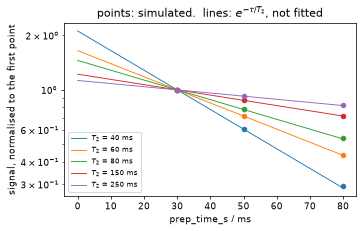

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
grid = np.linspace(0, max(PREPARED_S), 60)
for t2_s, measured in curves.items():
    normalised = np.asarray(measured) / measured[0]
    line, = ax.plot(np.asarray(PREPARED_S) * 1e3, normalised, 'o', ms=5)
    ax.plot(grid * 1e3, np.exp(-(grid - PREPARED_S[0]) / t2_s), lw=1.0, color=line.get_color(),
            label=f'$T_2$ = {t2_s * 1e3:.0f} ms')
ax.set(yscale='log', xlabel='prep_time_s / ms', ylabel='signal, normalised to the first point',
       title='points: simulated.  lines: $e^{-\\tau/T_2}$, not fitted')
ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()

Straight lines on a logarithmic axis, through points that were not fitted to them, over a factor
of six in $T_2$. The recovered value is within 2 % at every tissue, and the residual is one-sided
— always a little **long**, and more so the shorter $T_2$ is. Section 4 is where that comes
from.

---
## 3. The control that matters: $T_2$, not $T_2^*$

This is the measurement the module exists for. Without the refocusing train the magnetisation
sitting transverse for $\tau$ would decay at

$$\frac{1}{T_2^*} = \frac{1}{T_2} + \frac{1}{T_2'}$$

which is shorter, tissue-dependent *and* magnet-dependent. With the train, static dephasing is
reversed and $T_2'$ should not appear in the answer at all.

So: hold $T_2$ at 80 ms, sweep $T_2'$ over a factor of fifty, and watch what the fit does.

In [5]:
print(f'{"T2 prime / ms":>14}{"T2* / ms":>10}{"T2 fitted / ms":>16}')
for t2dash_s in (1000.0, 0.100, 0.050, 0.020):
    star_s = 1.0 / (1.0 / 0.080 + 1.0 / t2dash_s)
    fitted, _ = fitted_t2_s(t2_s=0.080, t2dash_s=t2dash_s)
    print(f'{t2dash_s * 1e3:14.0f}{star_s * 1e3:10.1f}{fitted * 1e3:16.1f}')

 T2 prime / ms  T2* / ms  T2 fitted / ms
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000252959 s
Compute Graph
Computing Graph: 0.019594207 s
Analyze Graph
Analyzing Graph: 0.000505209 s
Converting Rust -> Python: 0.009297542 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000355 s
Compute Graph
Computing Graph: 0.019359415 s
Analyze Graph
Analyzing Graph: 0.00046025 s
Converting Rust -> Python: 0.009157292 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000355583 s
Compute Graph
Computing Graph: 0.01855575 s
Analyze Graph
Analyzing Graph: 0.00050375 s
Converting Rust -> Python: 0.008973458 s
<<<< Rust <<<<
       1000000      80.0            80.8


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000437875 s
Compute Graph
Computing Graph: 0.019144084 s
Analyze Graph
Analyzing Graph: 0.000496583 s
Converting Rust -> Python: 0.008787709 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000413334 s
Compute Graph
Computing Graph: 0.019027209 s
Analyze Graph
Analyzing Graph: 0.0004675 s
Converting Rust -> Python: 0.008595083 s
<<<< Rust <<<<


...

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000343417 s
Compute Graph
Computing Graph: 0.01981454 s
Analyze Graph
Analyzing Graph: 0.000495417 s
Converting Rust -> Python: 0.008611416 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000412 s
Compute Graph
Computing Graph: 0.018534793 s
Analyze Graph
Analyzing Graph: 0.000446834 s
Converting Rust -> Python: 0.008298041 s
<<<< Rust <<<<
            50      30.8            79.3


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000485875 s
Compute Graph
Computing Graph: 0.020086957 s
Analyze Graph
Analyzing Graph: 0.000482417 s
Converting Rust -> Python: 0.008931292 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000341209 s
Compute Graph
Computing Graph: 0.019094542 s
Analyze Graph
Analyzing Graph: 0.000454042 s
Converting Rust -> Python: 0.009005125 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000322375 s
Compute Graph
Computing Graph: 0.019340668 s
Analyze Graph
Analyzing Graph: 0.000460542 s
Converting Rust -> Python: 0.008317708 s
<<<< Rust <<<<
            20      16.0            78.2


**$T_2^*$ falls from 80 ms to 16 ms — a factor of five — and the fitted value moves by 3 %.**
That is the refocusing train doing its job, stated as directly as a simulation can state it: the
preparation weights by the tissue's $T_2$, and the magnet's contribution to $T_2^*$ is refocused
away. The 3 % that is left is the train being made of real pulses with real gaps between them,
rather than the instantaneous inversions the ideal argument assumes.

Take the train out and this table would read $T_2^*$ down the last column — which is what a plain
gradient echo at a long echo time gives, and why a preparation is used instead.

---
## 4. Where the residual bias comes from

The fitted $T_2$ is consistently a little long, and by more at short $T_2$. The cause is $T_1$:
the preparation is not instantaneous, and longitudinal magnetisation recovers throughout it. That
adds a slowly growing term to the signal, which flattens the fitted decay.

It is a property of the sequence rather than of this implementation, so the honest thing is to
measure its size.

In [6]:
print(f'{"T1 / ms":>9}{"T2 fitted / ms":>16}{"error":>9}   (T2 = 40 ms throughout)')
for t1_s in (0.5, 1.0, 3.0, 20.0):
    fitted, _ = fitted_t2_s(t2_s=0.040, t1_s=t1_s)
    print(f'{t1_s * 1e3:9.0f}{fitted * 1e3:16.2f}{(fitted / 0.040 - 1) * 100:8.1f} %')

  T1 / ms  T2 fitted / ms    error   (T2 = 40 ms throughout)


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000307667 s
Compute Graph
Computing Graph: 0.01650279 s
Analyze Graph
Analyzing Graph: 0.000403708 s
Converting Rust -> Python: 0.007373917 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000463292 s
Compute Graph


Computing Graph: 0.014706 s
Analyze Graph
Analyzing Graph: 0.000377083 s
Converting Rust -> Python: 0.006570209 s
<<<< Rust <<<<
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00026825 s
Compute Graph
Computing Graph: 0.010327333 s
Analyze Graph
Analyzing Graph: 0.000245042 s
Converting Rust -> Python: 0.004608625 s
<<<< Rust <<<<


      500           41.59     4.0 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00019525 s
Compute Graph
Computing Graph: 0.017358959 s
Analyze Graph
Analyzing Graph: 0.00044375 s
Converting Rust -> Python: 0.008137417 s
<<<< Rust <<<<


...

>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000604125 s
Compute Graph
Computing Graph: 0.01650125 s
Analyze Graph
Analyzing Graph: 0.00040375 s
Converting Rust -> Python: 0.008027291 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000510958 s
Compute Graph
Computing Graph: 0.012440417 s
Analyze Graph
Analyzing Graph: 0.00028175 s
Converting Rust -> Python: 0.005515791 s
<<<< Rust <<<<
     3000           40.35     0.9 %
>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.00026775 s
Compute Graph


Computing Graph: 0.017870542 s
Analyze Graph
Analyzing Graph: 0.00043875 s
Converting Rust -> Python: 0.008749 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000497458 s
Compute Graph
Computing Graph: 0.016317459 s
Analyze Graph
Analyzing Graph: 0.000370125 s
Converting Rust -> Python: 0.008034834 s
<<<< Rust <<<<


>>>> Rust - compute_graph(...) >>>
Converting Python -> Rust: 0.000404959 s
Compute Graph
Computing Graph: 0.011191292 s
Analyze Graph
Analyzing Graph: 0.000267667 s
Converting Rust -> Python: 0.004749291 s
<<<< Rust <<<<
    20000           40.00    -0.0 %


At a $T_1$ of 20 s there is nothing to recover and the fit is exact to the last digit. At 500 ms
it is 4 % long. So a $T_2$ *measurement* from a preparation like this one needs the $T_1$ term
modelled; a $T_2$-*weighted image* does not care.

---
## 5. Limitations

**This is a contrast preparation, not a $T_2$ mapping method.** The bias above is one reason; the
others are that four preparation times is a thin fit, and that the shortest one here is 30 ms
because the pulses themselves do not fit into less.

**No $B_0$ or $B_1$ robustness is claimed.** Every simulation here ran at `B1 = 1.0` and zero
off-resonance. The composite pulses in this mode are more tolerant of a mis-set flip angle than
single hard pulses would be, and *how much* is exactly the claim that is not being made — an
adiabatic tip pair is what buys a quantitative version of it, and this mode does not have one.

**One voxel, no imaging.** The measurement is made at the centre of k-space of a single-voxel
phantom, so nothing here speaks to how the contrast survives a real readout, a real coil or a real
$B_0$ map.

---
## Summary

| | |
|---|---|
| **the weighting is real** | a known $T_2$ comes back from the slope of $\ln S$ against `prep_time_s`, within a few per cent from 40 to 250 ms |
| **and it is $T_2$, not $T_2^*$** | $T_2^*$ swept from 80 ms to 16 ms moves the fitted value by 3 % |
| **the bias is $T_1$** | +4 % at a 500 ms $T_1$, exact at 20 s: longitudinal recovery during the preparation, not an implementation error |
| **the fit is two-parameter** | because the amplitude contains the steady state and the tip-up's losses, which the preparation does not own |

## References

- M. A. Bernstein, K. F. King and X. J. Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004,
  §17.4.
- J. H. Brittain et al., *Magn. Reson. Med.* **33**, 689 (1995).
- MRzeroCore, [MRsources/MRzero-Core](https://github.com/MRsources/MRzero-Core).